Comparing number of Supernova between FlatIMF and LarsonIMF models 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.lines import Line2D
%matplotlib inline

# Import the custom package we designed
from pop3_cmb.cosmology import CAMBRunner
from pop3_cmb.faraday import FaradayModel
from pop3_cmb.spectrum import VVSpectrum
from pop3_cmb.config import CONSTANTS, COSMOLOGY, PARAMS

# Plotting settings for publication-quality figures
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [12]:
camb_run = CAMBRunner(COSMOLOGY, PARAMS['k_min'], PARAMS['k_max'], PARAMS['n_k_points'], PARAMS['z_min'], PARAMS['z_max'])
z_grid, k_grid, Plin = camb_run.get_linear_matter_power()

Note: redshifts have been re-sorted (earliest first)


In [13]:
fmLarson = FaradayModel(camb_run, PARAMS, CONSTANTS, k_grid, Plin, Model = 'LarsonIMF')
P_alpha = fmLarson.compute_P_alpha()

In [14]:
fmFlat = FaradayModel(camb_run, PARAMS, CONSTANTS, k_grid, Plin, Model = 'FlatIMF')
P_alpha = fmFlat.compute_P_alpha()

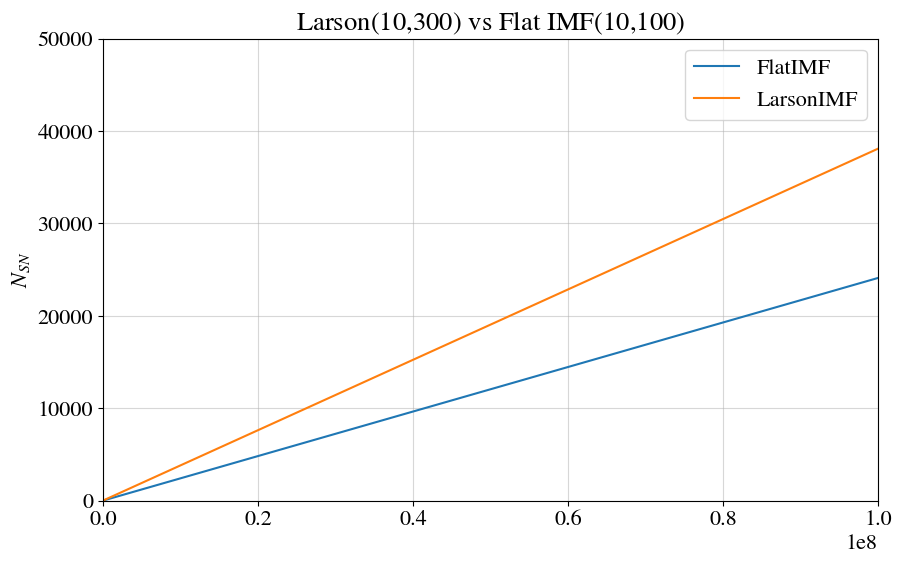

In [15]:
plt.figure()
plt.plot(fmFlat.M_grid, fmFlat.N_sn[0], label = 'FlatIMF') 
plt.plot(fmLarson.M_grid, fmLarson.N_sn[0], label = 'LarsonIMF') 
plt.xlim(0,10**8)
plt.ylim(0,50000)
plt.grid(True, alpha = 0.5)
plt.ylabel(r'$N_{SN}$')
plt.title(r'$\text{Larson(10,300) vs Flat IMF(10,100)}$')
plt.legend()

plt.show()

In [16]:
target=[10**6,10**7,10**8]
for target in target:
    idx = np.argmin(np.abs(fmFlat.M_grid - target))
    print(f'N_SN for M_Halo = {target:.0e} FlatIMF: {round(fmFlat.N_sn[0][idx])} LarsonIMF: {round(fmLarson.N_sn[0][idx])}')


N_SN for M_Halo = 1e+06 FlatIMF: 247 LarsonIMF: 390
N_SN for M_Halo = 1e+07 FlatIMF: 2524 LarsonIMF: 3990
N_SN for M_Halo = 1e+08 FlatIMF: 22998 LarsonIMF: 36351


In [17]:
import numpy as np
from scipy.integrate import simpson

def larson_phi(M, a=-1.35, Mc=20.0):
    return M**(a - 1.0) * np.exp(-Mc / M)

def mass_fraction(M1, M2, Mfull_min=10.0, Mfull_max=300.0):
    M_full = np.logspace(np.log10(Mfull_min), np.log10(Mfull_max), 5000)
    M_sub = np.logspace(np.log10(M1), np.log10(M2), 5000)

    full_mass = simpson(M_full * larson_phi(M_full), x=M_full)
    sub_mass = simpson(M_sub * larson_phi(M_sub), x=M_sub)

    return sub_mass / full_mass

f_range = mass_fraction(10.0, 100.0, 10.0, 300.0)

In [18]:
f_range

np.float64(0.6698595115038127)

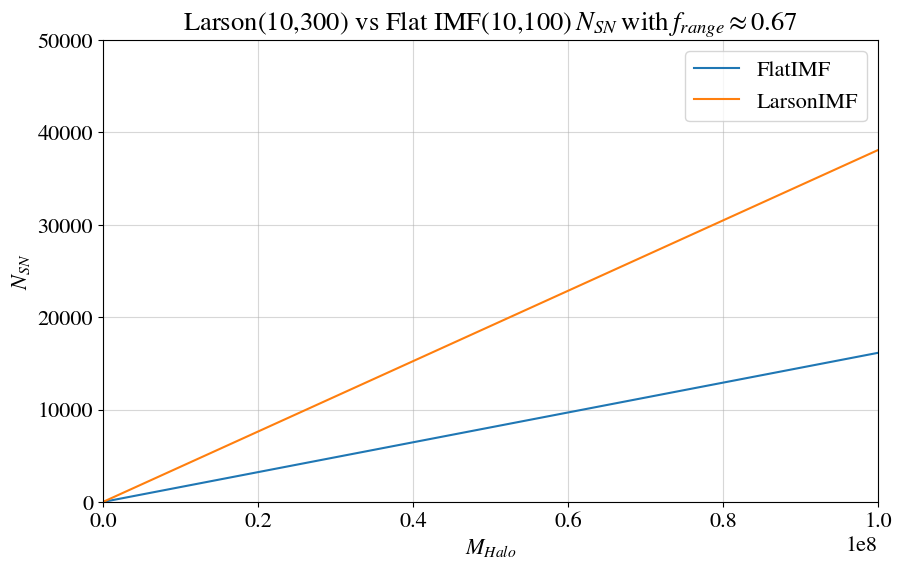

In [19]:
plt.figure()
plt.plot(fmFlat.M_grid, f_range * fmFlat.N_sn[0], label = 'FlatIMF') 
plt.plot(fmLarson.M_grid, fmLarson.N_sn[0], label = 'LarsonIMF') 
plt.xlim(0,10**8)
plt.ylim(0,50000)
plt.grid(True, alpha = 0.5)
plt.ylabel(r'$N_{SN}$')
plt.xlabel(r'$M_{Halo}$')
plt.title(r'$\text{Larson(10,300) vs Flat IMF(10,100)} \: N_{SN} \: \text{with} \: f_{range} \approx 0.67$')
plt.legend()

plt.show()

In [20]:
target=[10**6,10**7,10**8]
for target in target:
    idx = np.argmin(np.abs(fmFlat.M_grid - target))
    print(f'N_SN for M_Halo = {target:.0e} FlatIMF: {round(fmFlat.N_sn[0][idx]*f_range)} LarsonIMF: {round(fmLarson.N_sn[0][idx])}')


N_SN for M_Halo = 1e+06 FlatIMF: 165 LarsonIMF: 390
N_SN for M_Halo = 1e+07 FlatIMF: 1691 LarsonIMF: 3990
N_SN for M_Halo = 1e+08 FlatIMF: 15406 LarsonIMF: 36351
